In [1]:
import os
os.environ['SSL_CERT_FILE'] = '/Users/anderson/projects/hhh/cacert_with_somansa.pem'

In [2]:
from tool2 import load_cifar100_small, train_classifier, accuracy

Xtr, ytr, Xte, yte = load_cifar100_small(n_train=2000, n_test=500)
print('train:', Xtr.shape, 'test:', Xte.shape)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 169M/169M [05:26<00:00, 518kB/s]
/Users/anderson/.pyenv/versions/3.12.13/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train: torch.Size([2000, 3, 32, 32]) test: torch.Size([500, 3, 32, 32])


In [2]:
import sys, os
import torch
import torch.nn as nn
import torch.nn.functional as F
from tool2 import *   # 여러분은 tool 사용, tool2 X

seed_all(0)
DEV = device()
print('device:', DEV)  # 여러분은 cuda 

device: mps


# Convolution

In [3]:
x = torch.randn(1, 3, 32, 32)  # N=1, C=3, H=32, W=32
conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
y = conv(x)
print('input:', x.shape)
print('output:', y.shape)
print('params:', sum(p.numel() for p in conv.parameters()))
print('수동 계산:', conv_output_shape(32, K=3, S=1, P=1))
# print(y)

input: torch.Size([1, 3, 32, 32])
output: torch.Size([1, 16, 32, 32])
params: 448
수동 계산: 32


# Skip Connection

In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels))
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x) # Skip Connection
        return F.relu(out)
    
blk = BasicBlock(3, 16, stride=2)
x = torch.randn(1, 3, 28, 28)
print('input:', x.shape)
print('output:', blk(x).shape)

input: torch.Size([1, 3, 28, 28])
output: torch.Size([1, 16, 14, 14])


## Existing Small CNN

In [4]:
class SmallCnn(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallCnn()
model_summary(model, (1, 28, 28))

layer                    type          output shape                params
-------------------------------------------------------------------------
features.0               Conv2d        (1, 16, 28, 28)                160
features.1               ReLU          (1, 16, 28, 28)                  0
features.2               MaxPool2d     (1, 16, 14, 14)                  0
features.3               Conv2d        (1, 32, 14, 14)              4,640
features.4               ReLU          (1, 32, 14, 14)                  0
features.5               MaxPool2d     (1, 32, 7, 7)                    0
classifier.0             Flatten       (1, 1568)                        0
classifier.1             Linear        (1, 64)                    100,416
classifier.2             ReLU          (1, 64)                          0
classifier.3             Linear        (1, 10)                        650
-------------------------------------------------------------------------
TOTAL                                 

105866

In [6]:
class TinyResnet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.block1 = BasicBlock(16, 16, stride=1) # 28x28 -> 28x28
        self.block2 = BasicBlock(16, 32, stride=2) # 28x28 -> 14x14
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.gap(x).flatten(1)
        x = self.fc(x)
        return x
    
resnet = TinyResnet()
model_summary(resnet, (1, 28, 28))

layer                    type          output shape                params
-------------------------------------------------------------------------
stem.0                   Conv2d        (1, 16, 28, 28)                144
stem.1                   BatchNorm2d   (1, 16, 28, 28)                 32
stem.2                   ReLU          (1, 16, 28, 28)                  0
block1.conv1             Conv2d        (1, 16, 28, 28)              2,304
block1.bn1               BatchNorm2d   (1, 16, 28, 28)                 32
block1.conv2             Conv2d        (1, 16, 28, 28)              2,304
block1.bn2               BatchNorm2d   (1, 16, 28, 28)                 32
block1.shortcut          Identity      (1, 16, 28, 28)                  0
block2.conv1             Conv2d        (1, 32, 14, 14)              4,608
block2.bn1               BatchNorm2d   (1, 32, 14, 14)                 64
block2.conv2             Conv2d        (1, 32, 14, 14)              9,216
block2.bn2               BatchNorm2d  

19706

# Training Mnist

In [7]:
from tool2 import load_mnist_small, train_classifier, accuracy

Xtr, ytr, Xte, yte = load_mnist_small(n_train=2000, n_test=500)
print('train:', Xtr.shape, 'test:', Xte.shape)


train: torch.Size([2000, 1, 28, 28]) test: torch.Size([500, 1, 28, 28])


### Resnet

In [10]:
epochs=200
history = train_classifier(resnet, Xtr, ytr, epochs=epochs, lr=1e-3, batch_size=64, verbose=True)
print(f'test Accuracy: {accuracy(resnet, Xte, yte):.4}')

ep    0 | loss 1.1556
ep   20 | loss 0.1500
ep   40 | loss 0.0507
ep   60 | loss 0.0187
ep   80 | loss 0.0085
ep  100 | loss 0.0059
ep  120 | loss 0.0042
ep  140 | loss 0.0021
ep  160 | loss 0.0019
ep  180 | loss 0.0010
ep  199 | loss 0.0015
test Accuracy: 0.982


### Existing CNN Model

In [11]:
history2 = train_classifier(model, Xtr, ytr, epochs=epochs, lr=1e-3, batch_size=64, verbose=True)
print(f'test Accuracy: {accuracy(model, Xte, yte):.4}')

ep    0 | loss 0.2430
ep   20 | loss 0.0097
ep   40 | loss 0.0009
ep   60 | loss 0.0003
ep   80 | loss 0.0002
ep  100 | loss 0.0001
ep  120 | loss 0.0001
ep  140 | loss 0.0000
ep  160 | loss 0.0000
ep  180 | loss 0.0000
ep  199 | loss 0.0000
test Accuracy: 0.968


<Axes: title={'center': 'SmallCnn Loss'}, xlabel='epoch', ylabel='loss'>

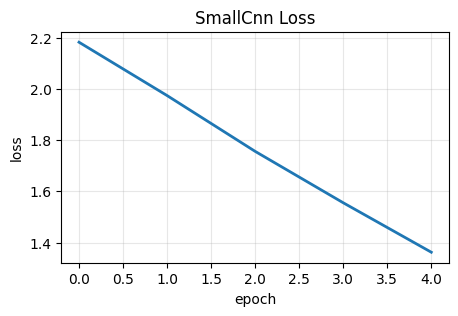

In [8]:
plot_loss(history, title='SmallCnn Loss')

first conv weight shape: torch.Size([16, 1, 3, 3])


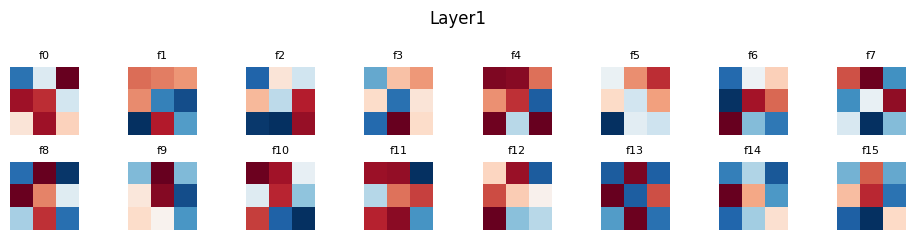

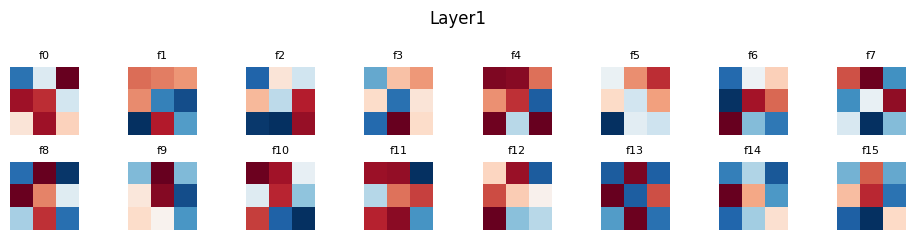

In [9]:
first_conv = model.features[0]
print('first conv weight shape:', first_conv.weight.shape)
show_conv_kernels(first_conv.weight, title='Layer1')


conv1 output shape: torch.Size([1, 16, 28, 28])


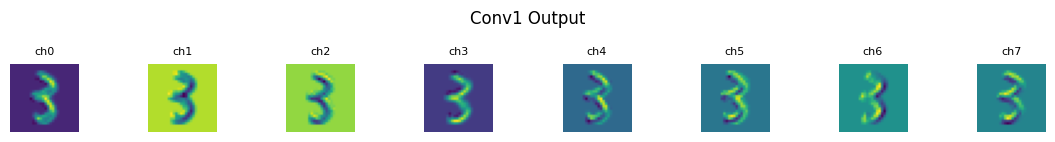

In [8]:
# 한 이미지 conv1 출력
model.eval()
with torch.no_grad():
    x = Xtr[0:1].to(DEV)  # (1, 1, 28, 28)
    conv1_out = model.features[0](x)  # (1, 16, 28, 28)
    print('conv1 output shape:', conv1_out.shape)
    show_feature_maps(conv1_out.cpu(), n_show=8, title='Conv1 Output')
    